# 5.0. - Descriptive Statistics

- Quando você recebe um novo conjunto de dados, uma das primeiras tarefas é encontrar formas de resumir esses dados de maneira compacta e compreensível.  Isso é exatamente o que as estatísticas descritivas fazem

- Diferente das estatísticas inferenciais (que tiram conclusões sobre populações a partir de amostras), as descritivas apenas descrevem o que está nos dados

- Para entender por que precisamos disso, basta olhar para um DataFrame com 176 linhas: simplesmente "olhar os dados" não nos diz nada útil. Precisamos de formas de resumir essas informações

In [5]:
import pandas as pd

afl_finalists = pd.read_csv('https://raw.githubusercontent.com/ethanweed/pythonbook/main/Data/afl_finalists.csv')
afl_margins = pd.read_csv('https://raw.githubusercontent.com/ethanweed/pythonbook/main/Data/afl_margins.csv')

print(afl_margins)

     afl.margins
0             56
1             31
2             56
3              8
4             32
..           ...
171           28
172           38
173           29
174           10
175           10

[176 rows x 1 columns]


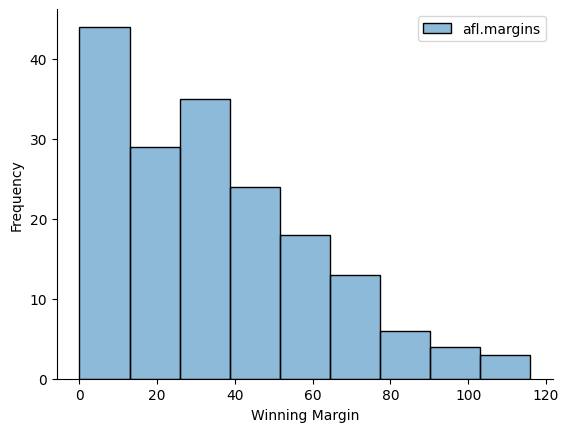

In [6]:
# Gerando um histograma da distribuição dos dados
import seaborn as sns

ax = sns.histplot(afl_margins)
ax.set(xlabel="Winning Margin", ylabel="Frequency")
sns.despine()

---

# 5.1. - Measures of Central Tendency

- A primeira coisa que geralmente queremos saber sobre um conjunto de dados é onde está o seu "centro", isso se chama medida de tendência central

- As três medidas mais usadas são: média (mean), mediana (median) e moda (mode). Às vezes também se usa a **média aparada (trimmed mean)

## 5.1.1. - The Mean

- A média é simplesmente a soma de todos os valores dividida pela quantidade de observações (média aritmética)

- Para os 5 primeiros valores da AFL (56, 31, 56, 8, 32):

$$\bar{X} = \frac{56 + 31 + 56 + 8 + 32}{5} = \frac{183}{5} = 36.60$$

- ou:

$$\bar{X} = \frac{1}{N} \sum_{i=1}^{N} X_i$$

  - $\bar{X}$ -> média
  - $N$ -> número total de observações
  - $X_i$ -> a i-ésima observação
  - $\sum$ -> símbolo de somatório

## 5.1.2. - Calculating the Mean in Python

In [7]:
# Jeito manual
(56 + 31 + 56 + 8 + 32) / 5

36.6

In [9]:
margins = afl_margins['afl.margins']

# Soma de todos os 176 valores
sum(margins)

6213

In [10]:
# Pegando só os 5 primeiros
margins[0:5]

,afl.margins
0,56
1,31
2,56
3,8
4,32


In [11]:
# Calculando a média dos 5 primeiros manualmente
sum(margins[0:5]) / 5

36.6

In [15]:
# Ou simplesmente usando o método .mean() do pandas
# Isso funciona porque margins é uma Series do pandas, não uma lista comum

# Confirmando o tipo da variável
print(type(margins))

print(margins[0:5].mean())

<class 'pandas.core.series.Series'>
36.6


In [16]:
# Se converter para lista, o .mean() para de funcionar
# Nesse caso é preciso importar statistics
import statistics
statistics.mean(margins)

35.30113636363637

## 5.1.3. - The Median

- A mediana é o valor do meio quando os dados estão ordenados

- Para os 5 primeiros valores (56, 31, 56, 8, 32), ordenados: 8, 31, **32**, 56, 56 -> mediana = 32

- Se houver um número par de observações, a mediana é a média dos dois valores centrais. Para os 6 primeiros valores (8, 14, 31, 32, 56, 56) -> mediana = (31 + 32) / 2 = 31.5

In [19]:
# Ordenando os dados para visualizar os valores centrais
sorted_margins = afl_margins.sort_values(by='afl.margins')
sorted_margins[84:92]  # Exibe o meio dos 176 valores

,afl.margins
58,29
150,29
165,29
117,30
1,31
4,32
123,32
136,33


In [21]:
# Basta usar .median()
margins.median()

30.5

## 5.1.4. - Mean or Median? What's the difference?

- A média é como o "centro de gravidade" dos dados, se você imaginar o histograma como um objeto sólido, a média é o ponto onde ele equilibraria num balancim

- A mediana é simplesmente o valor do meio, metade das observações está abaixo, metade acima

- Quando usar cada uma:
  - Dados nominais -> nem média nem mediana. Use a moda
  - Dados ordinais -> prefira a mediana, pois ela usa apenas a ordem (maior/menor), não os valores numéricos precisos
  - Dados de intervalo ou razão -> ambas funcionam, mas a média é sensível a valores extremos (outliers)

- Exemplo clássico: Bob ($50k), Kate ($60k) e Jane ($65k) numa mesa -> média = $58.333, mediana = $60k. Entra Bill ($100 milhões) -> média explode para $25 milhões, mediana sobe levemente para $62.5k. Se o interesse é a renda típica, a mediana é muito mais representativa

- Ponto importante: quando a distribuição é assimétrica (skewed), a média é "puxada" para a cauda onde estão os valores extremos, enquanto a mediana permanece mais próxima do "corpo" principal dos dados

## 5.1.5. - A Real Life Example

- Um exemplo concreto de como confundir média e mediana pode distorcer completamente uma análise: o caso dos preços de imóveis na Austrália

- O Commonwealth Bank comparou preços medianos de imóveis com rendas médias das famílias, chegando a uma razão preço/renda de 5.6

- A Demographia comparou preços medianos com rendas medianas, chegando a uma razão de aproximadamente 9

- A Demographia está correta. Misturar média de renda (que inclui os salários altíssimos dos super-ricos) com mediana de preços é metodologicamente inconsistente e, coincidência ou não, favorece o banco que tem interesse em mostrar que os imóveis estão acessíveis

## 5.1.6. - Trimmed Mean

- A média aparada (trimmed mean) é uma alternativa que tenta combinar o melhor dos dois mundos: a robustez da mediana com a utilização de mais informação da média

- Remove-se uma porcentagem dos valores mais extremos de cada lado (ex: os 5% menores e os 5% maiores) e calcula-se a média do restante

- É útil quando há outliers claros, mas você ainda quer aproveitar a maioria dos dados

In [22]:
from scipy.stats import trim_mean

# Removendo 5% de cada extremo
trim_mean(margins, 0.05)

np.float64(33.75)

## 5.1.7. - Mode

- A moda é o valor que aparece com mais frequência nos dados

- É a única medida de tendência central que faz sentido para dados nominais (ex: cores, categorias)

- Em distribuições contínuas a moda raramente é usada, mas em dados discretos ou categóricos ela é essencial

In [24]:
# Qual time apareceu mais vezes nas finais da AFL
afl_finalists['afl.finalists'].mode()

,afl.finalists
0,Geelong


---

# 5.2. - Measures of Variability

- Saber onde está o centro dos dados é importante, mas sozinho não conta a história toda. Dois conjuntos de dados podem ter a mesma média mas comportamentos completamente diferentes

- As medidas de variabilidade respondem à pergunta: o quanto os dados se espalham em torno do centro?

## 5.2.1. - Range

- O intervalo (range) é simplesmente a diferença entre o maior e o menor valor

- É fácil de calcular e entender, mas é extremamente sensível a outliers, um único valor absurdo distorce completamente o range

In [25]:
max(margins) - min(margins)

116

## 5.2.2. - Interquartile Range (IQR)

- O intervalo interquartil (IQR) é a diferença entre o 3º quartil (75%) e o 1º quartil (25%), ou seja, cobre a metade central dos dados

- É muito mais robusto a outliers do que o range simples, e é justamente o que a caixa de um boxplot representa

In [26]:
Q1 = margins.quantile(0.25)
Q3 = margins.quantile(0.75)
IQR = Q3 - Q1
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")

Q1: 12.75, Q3: 50.5, IQR: 37.75


## 5.2.3. - Mean Absolute Deviation (MAD)

- O desvio absoluto médio calcula a distância média de cada observação em relação à média, sem elevar ao quadrado

- É mais intuitivo do que a variância, mas menos usado na prática estatística formal

$$\text{MAD} = \frac{1}{N} \sum_{i=1}^{N} |X_i - \bar{X}|$$

In [27]:
# Calculando o MAD manualmente
import numpy as np
np.mean(np.abs(margins - margins.mean()))

np.float64(21.10123966942149)

## 5.2.4. - Variance

- A variância mede o quão dispersos os dados estão em torno da média, elevando as diferenças ao quadrado

- Por elevar ao quadrado, ela penaliza valores muito afastados da média de forma mais intensa

$$\text{Var}(X) = \frac{1}{N} \sum_{i=1}^{N} (X_i - \bar{X})^2$$

- Na prática, ao trabalhar com amostras (não populações inteiras), usa-se N-1 no denominador em vez de $N$, isso é a chamada correção de Bessel, que torna a estimativa menos enviesada

In [28]:
# O pandas usa N-1 por padrão (variância amostral)
margins.var()

679.8345129870132

## 5.2.5. - Standard Deviation

- O desvio padrão é simplesmente a raiz quadrada da variância

- A vantagem sobre a variância: o desvio padrão está na mesma unidade dos dados originais, tornando a interpretação muito mais intuitiva

$$\sigma = \sqrt{\text{Var}(X)}$$

- Por exemplo: se estamos medindo altura em cm, a variância seria em cm², mas o desvio padrão volta a ser em cm

In [29]:
margins.std()

26.073636359108278

## 5.2.6. - Median Absolute Deviation

- Uma versão robusta do desvio padrão, usando a mediana como referência ao invés da média

- Muito menos sensível a outliers

In [30]:
from scipy.stats import median_abs_deviation
median_abs_deviation(margins)

np.float64(19.5)

## 5.2.7. - Which Measure to Use?

- Para a maioria dos casos com dados de intervalo/razão sem muitos outliers: desvio padrão
- Quando há outliers ou a distribuição é assimétrica: IQR ou median absolute deviation
- O range simples raramente é informativo sozinho

---

# 5.3. - Skew and Kurtosis

- Além do centro e da dispersão, a forma da distribuição também importa

- Assimetria (skew): mede se a distribuição tem uma cauda mais longa de um lado
  - Skew positivo -> cauda para a direita (valores altos raros)
  - Skew negativo -> cauda para a esquerda (valores baixos raros)
  - Skew zero -> distribuição simétrica

- Curtose (kurtosis): mede se a distribuição tem picos altos/baixos em relação a uma curva normal
  - Curtose alta -> pico mais concentrado, caudas pesadas
  - Curtose baixa -> distribuição mais "achatada"

In [31]:
print("Skewness:", margins.skew())
print("Kurtosis:", margins.kurtosis())

Skewness: 0.7804075289401982
Kurtosis: 0.10109718805638757


---

# 5.4. - Getting an Overall Summary of a Variable

## 5.4.1. - "Describing" a Variable

- O método `.describe()` do pandas é a forma mais rápida de ter um resumo completo de uma variável de uma vez só

In [32]:
margins.describe()

,afl.margins
count,176.000000
mean,35.301136
std,26.073636
min,0.000000
25%,12.750000
50%,30.500000
75%,50.500000
max,116.000000


## 5.4.2. - "Describing" a DataFrame

- Também funciona direto no DataFrame completo, retornando o resumo de todas as colunas numéricas de uma vez

In [33]:
afl_margins.describe()

,afl.margins
count,176.000000
mean,35.301136
std,26.073636
min,0.000000
25%,12.750000
50%,30.500000
75%,50.500000
max,116.000000


---

# 5.5. - Standard Scores (Z-scores)

- Um **z-score** transforma um valor bruto em "quantos desvios padrões ele está afastado da média"

$$z_i = \frac{X_i - \bar{X}}{\hat{\sigma}}$$

- É extremamente útil para comparar valores de escalas diferentes — por exemplo, comparar o desempenho de alguém numa prova de matemática (média 60, dp 15) com numa prova de história (média 50, dp 5)

- Um z-score de +2 significa "esse valor está 2 desvios padrões acima da média" independente da escala original

In [34]:
# Calculando z-scores para as margens
z_scores = (margins - margins.mean()) / margins.std()
z_scores.head(10)

,afl.margins
0,0.793862
1,-0.164961
2,0.793862
3,-1.047078
4,-0.126608
5,-0.816961
6,0.026803
7,0.793862
8,-0.625196
9,-1.315549


---

# 5.6. - Correlations

## 5.6.1. - The Data

- Para explorar correlações, vamos usar o dataset `parenthood.csv`, que contém dados sobre horas de sono de Dan (`dan_sleep`), horas de sono do bebê (`baby_sleep`) e o nível de ranzinzice de Dan no dia seguinte (`dan_grump`)

In [35]:
df = pd.read_csv('https://raw.githubusercontent.com/ethanweed/pythonbook/main/Data/parenthood.csv')
df.head()

,dan_sleep,baby_sleep,dan_grump,day
0,7.59,10.18,56,1
1,7.91,11.66,60,2
2,5.14,7.92,82,3
3,7.71,9.61,55,4
4,6.68,9.75,67,5


## 5.6.2. - The Strength and Direction of a Relationship

- Uma correlação mede a relação linear entre duas variáveis

- Duas dimensões importam:
  - Direção: positiva (as duas variáveis sobem juntas) ou negativa (uma sobe enquanto a outra cai)
  - Força: quão forte é essa relação, de nenhuma (0) até perfeita (1 ou -1)

- No exemplo do dataset: intuitivamente esperamos que quanto menos Dan dorme, mais ranzinza ele fica -> correlação negativa

## 5.6.3. - The Correlation Coefficient

- O coeficiente de correlação de Pearson ($r$) é a medida mais usada:

$$r_{XY} = \frac{\sum_i (X_i - \bar{X})(Y_i - \bar{Y})}{(N-1) \hat{\sigma}_X \hat{\sigma}_Y}$$

- Varia entre -1 (correlação negativa perfeita) e +1 (correlação positiva perfeita)

- Um valor de 0 indica nenhuma relação linear

## 5.6.4. - Calculating Correlations in Python

In [36]:
# Correlação entre sono de Dan e seu nível de ranzinzice
df['dan_sleep'].corr(df['dan_grump'])

np.float64(-0.9033840374657273)

In [38]:
# Matriz de correlação de todas as variáveis numéricas
df.corr(numeric_only=True)

,dan_sleep,baby_sleep,dan_grump,day
dan_sleep,1.000000,0.627949,-0.903384,-0.098408
baby_sleep,0.627949,1.000000,-0.565964,-0.010434
dan_grump,-0.903384,-0.565964,1.000000,0.076479
day,-0.098408,-0.010434,0.076479,1.000000


## 5.6.5. - Interpreting a Correlation

- Não existe uma regra universal, mas uma orientação geral:
  - |r| < 0.1 -> negligível
  - 0.1 ≤ |r| < 0.3 -> fraca
  - 0.3 ≤ |r| < 0.5 -> moderada
  - |r| ≥ 0.5 -> forte

- orrelação não é causalidade. Duas variáveis podem ser fortemente correlacionadas sem que uma cause a outra — pode haver uma terceira variável explicando as duas, ou pode ser pura coincidência

---

# 5.7. - Handling Missing Values

- Dados do mundo real quase sempre têm valores faltantes. Ignorar isso pode causar erros silenciosos

## 5.7.1. - The Single Variable Case

In [39]:
import numpy as np

# Simulando dados com um valor ausente
dados_com_na = pd.Series([56, 31, np.nan, 8, 32])

# A média ignora NaN por padrão no pandas
print("Média ignorando NaN:", dados_com_na.mean())

# .isna() mostra onde estão os valores faltantes
print(dados_com_na.isna())

Média ignorando NaN: 31.75
0    False
1    False
2     True
3    False
4    False
dtype: bool


## 5.7.2. - Missing Values in Pairwise Calculations

- Na correlação, o pandas por padrão usa **pairwise deletion**: exclui apenas as linhas onde *alguma das duas variáveis envolvidas na correlação* é NaN, mantendo o máximo possível de dados

In [40]:
# Criando um dataframe com NaN para testar
df_teste = df.copy()
df_teste.loc[0, 'dan_sleep'] = np.nan

# O .corr() ainda funciona, ignorando as linhas com NaN no par envolvido
df_teste[['dan_sleep', 'dan_grump']].corr()

,dan_sleep,dan_grump
dan_sleep,1.000000,-0.903024
dan_grump,-0.903024,1.000000


---

# 5.8. - Summary

- As principais medidas de tendência central são média, mediana e moda, cada uma adequada para diferentes tipos de dados e situações

- As principais medidas de variabilidade são range, IQR, variância e desvio padrão

- A assimetria (skew) e a curtose (kurtosis) descrevem a forma da distribuição

- O método `.describe()` do pandas entrega um resumo rápido com as principais estatísticas

- Z-scores são úteis para padronizar e comparar valores de escalas diferentes

- A correlação de Pearson mede a força e direção de relações lineares entre variáveis, mas lembre sempre: correlação ≠ causalidade

- Valores faltantes (`NaN`) precisam de atenção, o pandas lida bem com eles por padrão, mas é sempre bom saber onde estão

---

# 5.9. - Epilogue: Good Descriptive Statistics are Descriptive!

- Estatísticas descritivas só são úteis quando realmente *descrevem* os dados de maneira honesta e transparente

- Escolher a medida errada (como comparar preços medianos com rendas médias, caso do banco australiano) pode distorcer completamente a realidade, intencionalmente ou não

- A boa prática é sempre reportar múltiplas medidas quando relevante, justificar as escolhas feitas e estar atento às suposições por trás de cada métrica
